In [22]:
"""
iapp_frequency.py
==================
Curva f-I (frequência de disparo x corrente aplicada) comparando o
modelo Hodgkin-Huxley original com o modelo hibrido identificado por
SINDy (xNa via biblioteca com Heaviside, xK via biblioteca polinomial).

Para cada valor de I_app em um vetor de correntes, os dois modelos sao
simulados a partir do repouso, o transiente inicial e descartado, e a
frequencia de disparo (picos de potencial de acao) e estimada.
"""
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
import scienceplots          # noqa: F401
plt.style.use(["science", "ieee", "no-latex"])
from scipy.signal import find_peaks

from hh_model_v2 import (gK, EK, gNa, ENa, gL, EL, Cm,
                          alpha_m, beta_m, alpha_h, beta_h,
                          alpha_n, beta_n,
                          simulate_hh, rest_ic)

os.makedirs("outputs_comparison", exist_ok=True)


In [23]:
# ══════════════════════════════════════════════════════════════
# Equacoes identificadas (hardcoded) -- mesmas do script original
# ══════════════════════════════════════════════════════════════

def H(x):
    return np.heaviside(x, 0.5)

V_GATE_NA = -40.0

def dxNa_dt(V, xNa):
    Hm = H(V_GATE_NA - V)   # H(-40 - V)
    Hp = H(V - V_GATE_NA)   # H(V + 40)
    return (  9.5857e-01 * Hm       * (1-xNa)
            + 4.8522e-01 * Hm * V   * xNa
            + 4.1550e-02 * Hm * V   * (1-xNa)
            + 1.6413e-02 * Hm * V**2 * xNa
            + 6.0058e-04 * Hm * V**2 * (1-xNa)
            + 1.7481e-04 * Hm * V**3 * xNa
            + 2.8939e-06 * Hm * V**3 * (1-xNa)
            - 9.2165e+00 * Hp        * xNa
            + 1.0691e+00 * Hp        * (1-xNa)
            - 1.1254e-01 * Hp * V   * xNa
            + 4.3061e-02 * Hp * V   * (1-xNa)
            + 4.9414e-04 * Hp * V**2 * (1-xNa))

def dxK_dt(V, xK):
    return (  3.6987e-01 * xK
            + 1.0101e-01 * (1-xK)
            + 1.8080e-02 * V    * xK
            + 1.8574e-03 * V    * (1-xK)
            + 1.4947e-04 * V**2 * xK
            + 9.4717e-07 * V**3 * xK
            + 1.5333e-09 * V**4 * (1-xK))


def simulate_sindy(I_app=10., T=100., dt=0.01, y0=None):
    """
    Simula o modelo hibrido HH em que xNa e xK evoluem pelas equacoes
    identificadas por SINDy. Estado: (V, xNa, xK).
    """
    t = np.arange(0, T + dt, dt)

    if y0 is None:
        y0 = rest_ic()
    V0, m0, h0, n0 = y0
    xNa0 = m0**3 * h0
    xK0  = n0**4

    V, xNa, xK = V0, xNa0, xK0
    V_arr   = np.zeros(len(t)); V_arr[0]   = V
    xNa_arr = np.zeros(len(t)); xNa_arr[0] = xNa
    xK_arr  = np.zeros(len(t)); xK_arr[0]  = xK

    for i in range(1, len(t)):
        INa = gNa * xNa * (V - ENa)
        IK  = gK  * xK  * (V - EK)
        IL  = gL         * (V - EL)

        dV   = (I_app - INa - IK - IL) / Cm
        dxna = dxNa_dt(V, xNa)
        dxk  = dxK_dt(V, xK)

        V   += dt * dV
        xNa  = float(np.clip(xNa + dt * dxna, 0., 1.3))
        xK   = float(np.clip(xK  + dt * dxk,  0., 1.3))

        V_arr[i]   = V
        xNa_arr[i] = xNa
        xK_arr[i]  = xK

    return t, V_arr, xNa_arr, xK_arr


In [24]:
# ══════════════════════════════════════════════════════════════
# Deteccao de picos / frequencia de disparo
# ══════════════════════════════════════════════════════════════

def spike_frequency(t, V, threshold=0.0, discard_ms=50.0):
    """
    Conta picos (potenciais de acao) em V(t) acima de `threshold` mV,
    descartando os primeiros `discard_ms` ms (transiente inicial), e
    retorna a frequencia de disparo em Hz.

    `distance` no find_peaks (1 ms) evita contar o mesmo pico duas
    vezes por ruido numerico na subida/descida do potencial de acao.
    """
    mask = t >= discard_ms
    t_win, V_win = t[mask], V[mask]
    if len(t_win) < 2:
        return 0.0

    dt = t[1] - t[0]
    peaks, _ = find_peaks(V_win, height=threshold, distance=max(1, int(1.0 / dt)))
    n_spikes = len(peaks)
    duration_s = (t_win[-1] - t_win[0]) / 1000.0  # ms -> s
    if duration_s <= 0:
        return 0.0
    return n_spikes / duration_s


I_app=   0.0  |  freq_HH=   0.00 Hz  |  freq_SINDy=   0.00 Hz
I_app=   2.0  |  freq_HH=   0.00 Hz  |  freq_SINDy=   0.00 Hz
I_app=   4.0  |  freq_HH=   0.00 Hz  |  freq_SINDy=   0.00 Hz
I_app=   6.0  |  freq_HH=   0.00 Hz  |  freq_SINDy=   0.00 Hz
I_app=   8.0  |  freq_HH=  64.00 Hz  |  freq_SINDy=   0.00 Hz
I_app=  10.0  |  freq_HH=  68.00 Hz  |  freq_SINDy=  68.00 Hz
I_app=  12.0  |  freq_HH=  72.00 Hz  |  freq_SINDy=  80.00 Hz
I_app=  14.0  |  freq_HH=  76.00 Hz  |  freq_SINDy=  84.00 Hz
I_app=  16.0  |  freq_HH=  80.00 Hz  |  freq_SINDy=  88.00 Hz
I_app=  18.0  |  freq_HH=  80.00 Hz  |  freq_SINDy=  96.00 Hz
I_app=  20.0  |  freq_HH=  84.00 Hz  |  freq_SINDy= 100.00 Hz
I_app=  22.0  |  freq_HH=  88.00 Hz  |  freq_SINDy= 100.00 Hz
I_app=  24.0  |  freq_HH=  92.00 Hz  |  freq_SINDy= 104.00 Hz
I_app=  26.0  |  freq_HH=  96.00 Hz  |  freq_SINDy= 108.00 Hz
I_app=  28.0  |  freq_HH=  96.00 Hz  |  freq_SINDy= 112.00 Hz
I_app=  30.0  |  freq_HH= 100.00 Hz  |  freq_SINDy= 116.00 Hz
I_app=  

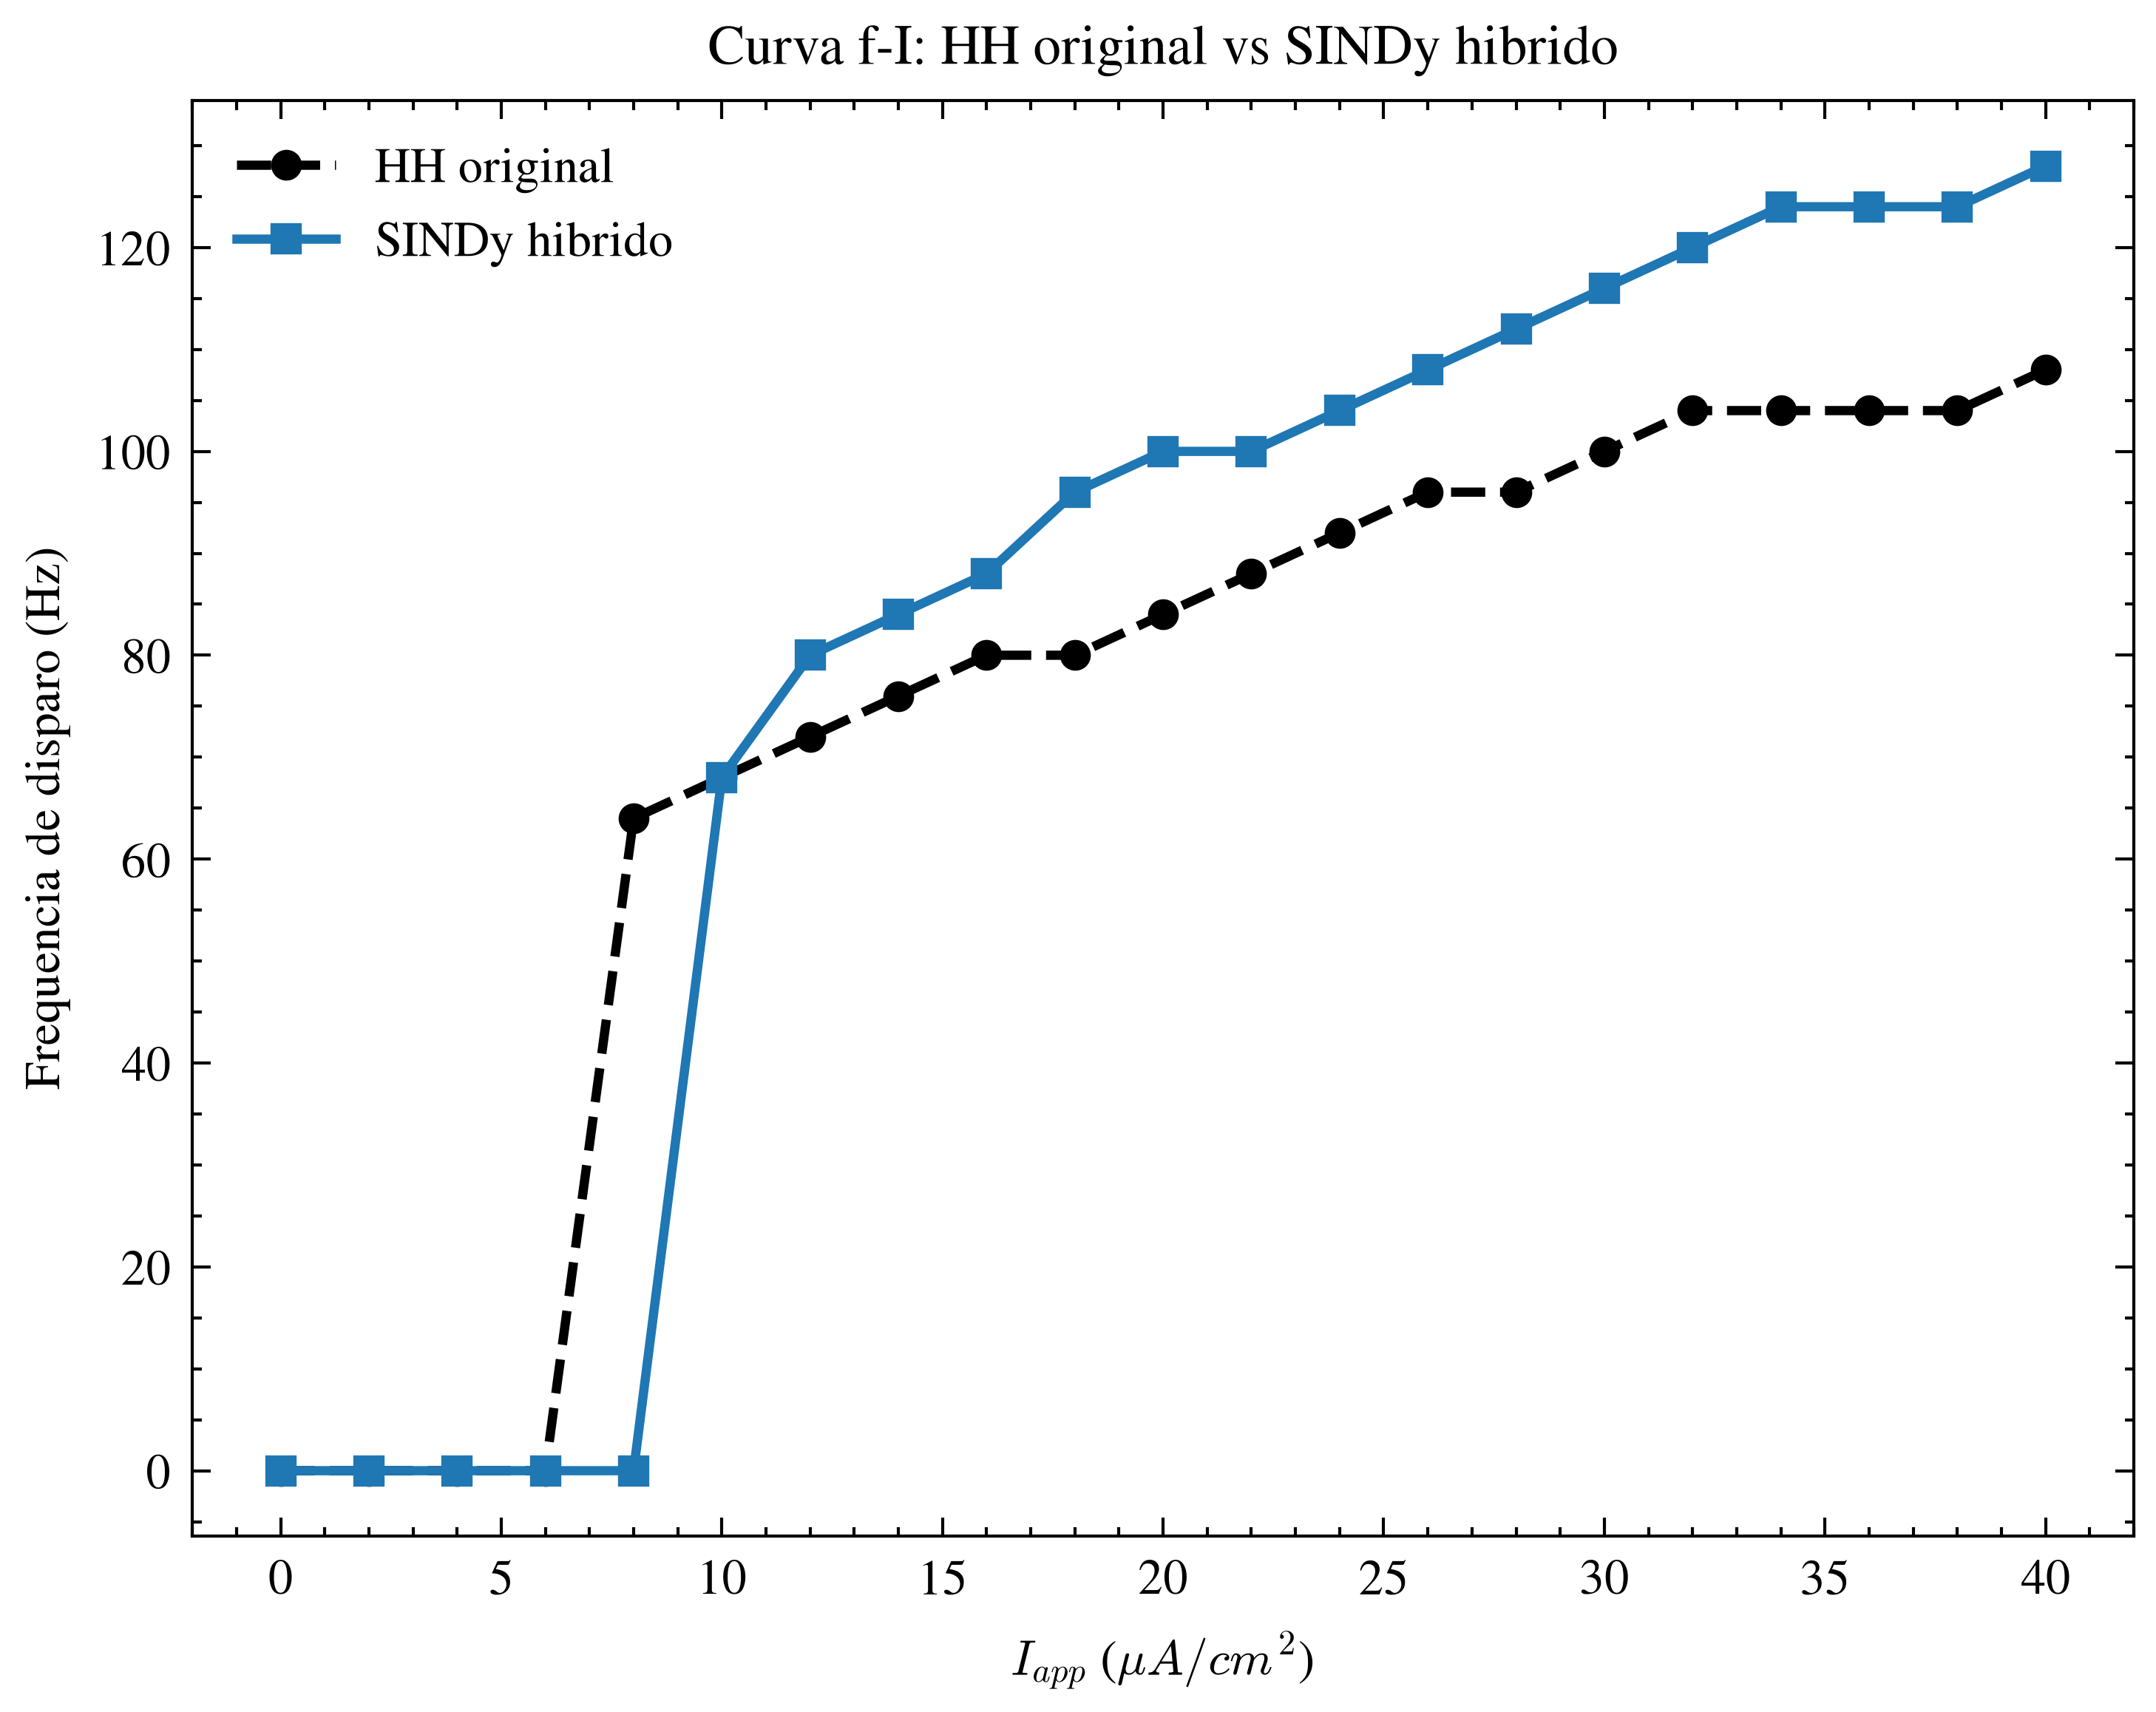


Saved: outputs_comparison/fi_curve_hh_vs_sindy.png


In [25]:
# ══════════════════════════════════════════════════════════════
# Varredura em I_app: curva f-I para os dois modelos
# ══════════════════════════════════════════════════════════════
if __name__ == "__main__":

    T          = 300.0     # ms -- tempo suficiente para regime periodico
    DT         = 0.01
    DISCARD_MS = 50.0      # descarta transiente inicial da contagem
    THRESHOLD  = 0.0        # mV -- limiar de deteccao de pico

    # Vetor de correntes aplicadas (~20 valores)
    #I_APP_VALUES = np.array([0, 1, 2, 5, 10, 15, 20, 25, 30, 35, 40, 45], dtype=float)
    I_APP_VALUES = np.linspace(0.0,40.0,21)

    ic = rest_ic()  # mesma condicao inicial (repouso) para todas as correntes

    freq_hh    = np.zeros(len(I_APP_VALUES))
    freq_sindy = np.zeros(len(I_APP_VALUES))

    for i, I_app in enumerate(I_APP_VALUES):
        # --- HH original ---
        t_hh, V_hh, m_hh, h_hh, n_hh = simulate_hh(I_app, T, DT, y0=ic)
        freq_hh[i] = spike_frequency(t_hh, V_hh, THRESHOLD, DISCARD_MS)

        # --- SINDy hibrido ---
        t_id, V_id, xNa_id, xK_id = simulate_sindy(I_app, T, DT, y0=ic)
        freq_sindy[i] = spike_frequency(t_id, V_id, THRESHOLD, DISCARD_MS)

        print(f"I_app={I_app:6.1f}  |  freq_HH={freq_hh[i]:7.2f} Hz  |  "
              f"freq_SINDy={freq_sindy[i]:7.2f} Hz")

    # ── Plot: curva f-I sobreposta ──────────────────────────────
    colors = plt.cm.tab10(np.linspace(0, 1, 10))

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(I_APP_VALUES, freq_hh, "o--", color="k",
            label="HH original", lw=1.5, ms=4)
    ax.plot(I_APP_VALUES, freq_sindy, "s-", color=colors[0],
            label="SINDy hibrido", lw=1.5, ms=4)

    ax.set(xlabel=r"$I_{app}$ ($\mu A/cm^2$)",
           ylabel="Frequencia de disparo (Hz)")
    ax.set_title("Curva f-I: HH original vs SINDy hibrido", fontsize=9)
    ax.legend(fontsize=8, loc="best")

    plt.tight_layout()
    fname = "outputs_comparison/fi_curve_hh_vs_sindy.png"
    plt.savefig(fname, dpi=140)
    plt.show()
    print(f"\nSaved: {fname}")
